In [2]:
import cv2
import pandas
import numpy as np
import matplotlib.pyplot as plt
from typing import List
from pathlib import Path
from skimage.measure import regionprops_table, regionprops

In [ ]:
class DiscSegmentation:


    def __init__(self, image_path: str | Path):
        self.image_rgb = cv2.imread(image_path, cv2.IMREAD_COLOR_RGB)
        self.edges = self.preprocessing(self.image_rgb)
        self.image_shape = self.edges.shape
    

    def preprocessing(self, image_rgb: np.ndarray) -> np.ndarray:
        image_luv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LUV)
        edges = cv2.Canny(image_luv, 100, 200)
        return edges


    def get_mask(self, contour: np.ndarray) -> np.ndarray:
        return np.uint8(cv2.drawContours(np.zeros(self.image_shape), [contour], 0, (255, 255, 255), -1)/255)


    def compute_circularity(self, contour: np.ndarray) -> float:
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, closed=True)
        if perimeter == 0:
            return -1
        return 4 * np.pi * area / perimeter**2


    def sort_contours(self, detected_contours: np.ndarray) -> List[np.ndarray]:
        masks = [self.get_mask(detected_contour) for detected_contour in detected_contours]
        good_contours = []
        for i, mask in enumerate(masks):
            region = regionprops(mask)[0]
            conditions = self.compute_circularity(detected_contours[i]) > 0.5 and region["area"] <= 8000 and region["area"] >= 500
            if conditions:
                good_contours.append(detected_contours[i])
        sorted_contours = sorted(good_contours, key=lambda contour: cv2.minEnclosingCircle(contour)[1])
        return sorted_contours


    def get_both_contours(self) -> None:
        detected_contours, _ = cv2.findContours(self.edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
        sorted_contours = self.sort_contours(detected_contours)
        radii = [cv2.minEnclosingCircle(contour)[1] for contour in sorted_contours]
        diffs = np.diff(radii)
        index_max_diff = np.argmax(diffs)
        self.red_contour = sorted_contours[index_max_diff]
        self.yellow_contour = sorted_contours[-1]


    def compute_stats(self, dislay_table: bool) -> pandas.DataFrame:
        print(self.red_contour)
        circularities = [self.compute_circularity(self.red_contour), self.compute_circularity(self.yellow_contour)]
        properties = ["centroid", "orientation", "axis_major_length", "axis_minor_length", "eccentricity", "area", "perimeter", "solidity"]

        red_stats = pandas.DataFrame(regionprops_table(self.get_mask(self.red_contour), properties=properties))
        red_stats["circularity"] = circularities[0]
        red_stats["convexity"] = cv2.isContourConvex(self.red_contour)
        red_stats.rename(index={0: "Red"}, inplace=True)

        yellow_stats = pandas.DataFrame(regionprops_table(self.get_mask(self.yellow_contour), properties=properties))
        yellow_stats["circularity"] = circularities[1]
        yellow_stats["convexity"] = cv2.isContourConvex(self.yellow_contour)
        yellow_stats.rename(index={0: "Yellow"}, inplace=True)

        stats = pandas.concat([red_stats, yellow_stats])
        self.stats = stats
        if dislay_table:
            display(self.stats)
        return self.stats


    def show_results(self) -> None:
        yellow_filled = cv2.drawContours(np.copy(self.image_rgb), [self.yellow_contour], 0, (255, 255, 0), -1)
        both_filled = cv2.drawContours(np.copy(yellow_filled), [self.red_contour], 0, (255, 0, 0), -1)
        plt.imshow(both_filled)
        plt.show()

,centroid-0,centroid-1,orientation,axis_major_length,axis_minor_length,eccentricity,area,perimeter,solidity,circularity,convexity
Red,506.635413,512.748287,0.022346,71.143854,49.982645,0.711627,2773.0,199.438600,0.983333,0.848115,False
Yellow,502.600235,512.625661,-0.143935,98.142404,88.626402,0.429559,6804.0,306.450793,0.988953,0.892245,False


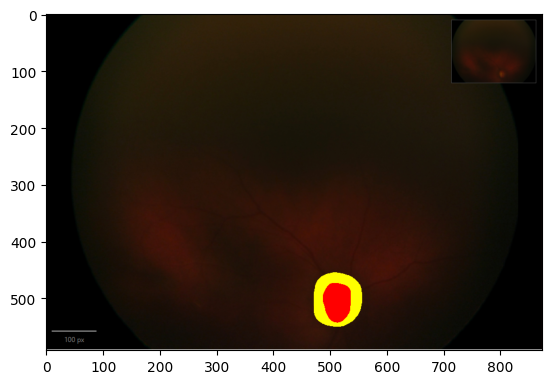

In [23]:
# Test Pipeline
image_path = Path("../Labelized_Data/CAEN/KOE-2428-29-OD.tif")
segmentation = DiscSegmentation(image_path)
segmentation.get_both_contours()
stats = segmentation.compute_stats(dislay_table=True)
segmentation.show_results()

In [7]:
import os
# Get caracteristics for all pictures 
caen_path = Path("../Labelized_Data/CAEN")
cherbourg_path = Path("../Labelized_Data/CHERBOURG")

In [20]:
def caracterisation_folder(path, filename):
    red_list = pandas.DataFrame()
    yellow_list = pandas.DataFrame()
    for entry in os.scandir(path):
        if(entry.is_file()):
            segmentation = DiscSegmentation(entry.path)
            current =  segmentation.compute_stats(dislay_table=False).iloc
            current_red = current[0]
            current_yellow = current[1]

            # axes (major/minor), eccentricity, area, solidity, circularity, convexity, mean centroid 
            #  CDR (Cup-to-Disc ratio) = aire rouge / aire jaune, et le VCDR et HCDR (Vertical et Horizontal) = axis_major rouge / axis_major jaune et axis_minor rouge / axis_minor jaune
            print(current_red)
            red_list[entry.name] = current_red
            yellow_list[entry.name] = current_yellow
    yellow_list.T.to_csv('./caracterisation/yellow_' + filename + '.csv', index=True)
    red_list.T.to_csv('./caracterisation/red_' + filename + '.csv', index=True)

In [21]:
caracterisation_folder('../Labelized_Data/CHERBOURG', "cherbourg")

AttributeError: 'DiscSegmentation' object has no attribute 'red_contour'

In [121]:
caracterisation_folder('../Labelized_Data/CAEN', "caen")